# **Seismic Inversion FWI - FPN**

# **0. Install tensorflow probability**


In [1]:
import tensorflow as tf
print(tf.__version__)

2026-09-07 22:30:00.688049: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-07 22:30:00.751388: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-07 22:30:00.753566: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-09-07 22:30:00.753575: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore 

2.11.0


# **1. Python libraries**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import string
from matplotlib.ticker import FuncFormatter
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

In [3]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


2026-09-07 22:30:02.125590: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-09-07 22:30:02.130459: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-09-07 22:30:02.130495: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-09-07 22:30:02.130531: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-09-07 22:30:02.130555: W tensorflow/c

In [4]:
!nvidia-smi

Mon Sep  7 22:30:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070 Ti     Off |   00000000:01:00.0  On |                  N/A |
|  0%   37C    P8             21W /  310W |     413MiB /   8192MiB |     17%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **2. Paths**

### **2.1. Traces - InputData**

In [5]:
dirTraceTrain = "../Data/kimberlina_co2_train_data"
dirTraceVal = "../Data/kimberlina_co2_test_data"

### **2.2. Velocity - OutputData**

In [6]:
dirModelTrain = "../Model/kimberlina_co2_train_label"
dirModelVal = "../Model/kimberlina_co2_test_label"

### **2.3. Directory for saved trained models**

In [7]:
dirModelTrained="../ModelTrained/"
dirModel="../Model/"

### **2.4. Trained models directory**

In [8]:
dirImages = "../Images/"

# **3. Load list Paths**

### **3.1. Load list path Data Traces - Input**

In [9]:
TracePaths_train = sorted(
    os.path.join(dirTraceTrain, f)
    for f in os.listdir(dirTraceTrain)
    if f.endswith(".npz")
)


In [10]:
len(TracePaths_train)

15000

In [11]:
TracePaths_val = sorted(
    os.path.join(dirTraceVal, f)
    for f in os.listdir(dirTraceVal)
    if f.endswith(".npz")
)

In [12]:
len(TracePaths_val)

4430

### **3.2. Load Path Data Velocity - Output**

In [13]:
ModelPaths_train = sorted(
    os.path.join(dirModelTrain, f)
    for f in os.listdir(dirModelTrain)
    if f.endswith(".npz")
)

In [14]:
len(ModelPaths_train)

15000

In [15]:
ModelPaths_val = sorted(
    os.path.join(dirModelVal, f)
    for f in os.listdir(dirModelVal)
    if f.endswith(".npz")
)

In [16]:
len(ModelPaths_val)

4430

### **3.3.Splits**

In [17]:
# Semilla para reproducibilidad
random.seed(42)

nTest = 1000   # número de rutas para el test set, extraídas de train
nCal = 100    # número de rutas para el calibration set, extraídas de train

assert len(TracePaths_train) == len(ModelPaths_train), \
    "TracePaths_train y ModelPaths_train deben tener el mismo largo (pares input/output)"

# Generar índices mezclados para mantener la correspondencia input-output
indices = list(range(len(TracePaths_train)))
random.shuffle(indices)

test_idx = indices[:nTest]
cal_idx = indices[nTest:nTest + nCal]
train_idx = indices[nTest + nCal:]

# Aplicar los índices a ambas listas (trace y model) para no romper la correspondencia
TracePaths_test = [TracePaths_train[i] for i in test_idx]
ModelPaths_test = [ModelPaths_train[i] for i in test_idx]

TracePaths_cal = [TracePaths_train[i] for i in cal_idx]
ModelPaths_cal = [ModelPaths_train[i] for i in cal_idx]

TracePaths_train_final = [TracePaths_train[i] for i in train_idx]
ModelPaths_train_final = [ModelPaths_train[i] for i in train_idx]

print(f"Train final: {len(TracePaths_train_final)} pares")
print(f"Test: {len(TracePaths_test)} pares")
print(f"Calibration: {len(TracePaths_cal)} pares")
print(f"Validation (sin cambios): {len(TracePaths_val)} pares")

Train final: 13900 pares
Test: 1000 pares
Calibration: 100 pares
Validation (sin cambios): 4430 pares


### **3.4. Vmin and Vmax - Set Train**

In [18]:
vmin_global = np.inf
vmax_global = -np.inf

for path in ModelPaths_train:
    label = np.load(path)['label']
    vmin_global = min(vmin_global, label.min())
    vmax_global = max(vmax_global, label.max())

print(f"Min velocity: {vmin_global:.2f} m/s")
print(f"Max velocity: {vmax_global:.2f} m/s")

Min velocity: 951.82 m/s
Max velocity: 2546.00 m/s


# **4. Batch Creation**

In [19]:
import cv2

class SeismicSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        trace_paths,
        model_paths,
        batch_size=8,
        shuffle=True,
        target_size=(288,96)#(128, 128)
    ):
        self.trace_paths = trace_paths
        self.model_paths = model_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.target_size = target_size
        self.n_models = len(trace_paths)
        self.indices = np.arange(self.n_models)
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(self.n_models / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[
            idx * self.batch_size : (idx + 1) * self.batch_size
        ]

        X_batch = []
        y_batch = []

        H, W = self.target_size

        for i in batch_indices:
            X = np.load(self.trace_paths[i])['data']   # (9, 1251, 101)
            y = np.load(self.model_paths[i])['label']  # (401, 141)

            y_resized = cv2.resize(y, (W, H), interpolation=cv2.INTER_LINEAR)  # (128, 128)

            X_batch.append(X)
            y_batch.append(y_resized)

        X_batch = np.asarray(X_batch, dtype=np.float32)   # (batch, 9, 1251, 101)
        y_batch = np.asarray(y_batch, dtype=np.float32)   # (batch, 128, 128)

        X_batch = X_batch.transpose(0, 2, 3, 1)           # (batch, 1251, 101, 9)
        y_batch = y_batch[:, :, :, np.newaxis]             # (batch, 128, 128, 1)

        v_min = vmin_global#np.min(y_batch, axis=(1, 2, 3), keepdims=True)
        v_max = vmax_global#np.max(y_batch, axis=(1, 2, 3), keepdims=True)
        
        y_batch = (y_batch - v_min) / (v_max - v_min)
        
        return X_batch, y_batch

In [20]:
nbatch=8
train_seq = SeismicSequence(
    trace_paths=TracePaths_train_final,
    model_paths=ModelPaths_train_final,
    batch_size=nbatch,
    shuffle=True
)

test_seq = SeismicSequence(
    trace_paths=TracePaths_test,
    model_paths=ModelPaths_test,
    batch_size=nbatch,
    shuffle=False
)

val_seq = SeismicSequence(
    trace_paths=TracePaths_val,
    model_paths=ModelPaths_val,
    batch_size=nbatch,
    shuffle=False
)

cal_seq = SeismicSequence(
    trace_paths=TracePaths_cal,
    model_paths=ModelPaths_cal,
    batch_size=nbatch,
    shuffle=False
)


In [21]:
print(f"Train batches: {len(train_seq)}")
print(f"Test batches: {len(test_seq)}")
print(f"Validation batches: {len(val_seq)}")
print(f"Calibration batches: {len(cal_seq)}")

Train batches: 1738
Test batches: 125
Validation batches: 554
Calibration batches: 13


In [22]:
print(len(TracePaths_train_final), len(ModelPaths_train_final))
print(len(TracePaths_val), len(ModelPaths_val))
print(len(TracePaths_test), len(ModelPaths_test))
print(len(TracePaths_cal), len(ModelPaths_cal))

13900 13900
4430 4430
1000 1000
100 100


In [23]:
for x,y in train_seq:
    break
x.shape,y.shape

((8, 1251, 101, 9), (8, 288, 96, 1))

# **5. Model Building**

In [24]:
import segmentation_models as sm

Segmentation Models: using `keras` framework.


In [25]:
BACKBONE = 'seresnet50'

In [26]:
inp = layers.Input(shape=(1251, 101, 9))
x = layers.Conv2D(9, 1, activation="relu")(inp)
x = layers.MaxPooling2D(pool_size=(2, 1))(x)

x = layers.Conv2D(9, 1, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=(2, 1))(x)

2026-09-07 22:30:18.657362: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [27]:
x.shape

TensorShape([None, 312, 101, 9])

In [28]:
x = layers.Resizing(288, 96, interpolation="bilinear")(x)

In [29]:
x.shape

TensorShape([None, 288, 96, 9])

In [30]:
# define model
BB = sm.FPN(BACKBONE, input_shape=(288,96,9), decoder_filters=(2048,1024, 512, 256, 128, 64, 32), decoder_use_batchnorm=True, pyramid_use_batchnorm=True,encoder_weights=None, pyramid_dropout=0.1,activation="gelu", classes=1)(x)

/home/alejo/anaconda3/envs/AutoEncoder/lib/python3.7/site-packages/tensorflow_probability/python/layers/util.py:102: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  trainable=trainable)
/home/alejo/anaconda3/envs/AutoEncoder/lib/python3.7/site-packages/tensorflow_probability/python/layers/util.py:112: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  trainable=trainable)


In [31]:
model2=Model(inp,BB)

In [32]:
model2.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1251, 101, 9)]    0         
                                                                 
 conv2d (Conv2D)             (None, 1251, 101, 9)      90        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 625, 101, 9)      0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 625, 101, 9)       90        
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 312, 101, 9)      0         
 2D)                                                             
                                                                 
 resizing (Resizing)         (None, 288, 96, 9)        0   

In [33]:
for layer in model2.get_layer("model_1").layers:
    print(layer.name, layer.output_shape)

input [(None, 288, 96, 9)]
zero_padding2d (None, 294, 102, 9)
conv2d_2 (None, 144, 48, 64)
batch_normalization (None, 144, 48, 64)
activation (None, 144, 48, 64)
zero_padding2d_1 (None, 146, 50, 64)
max_pooling2d_2 (None, 72, 24, 64)
conv2d_3 (None, 72, 24, 64)
batch_normalization_1 (None, 72, 24, 64)
activation_1 (None, 72, 24, 64)
zero_padding2d_2 (None, 74, 26, 64)
conv2d_4 (None, 72, 24, 64)
batch_normalization_2 (None, 72, 24, 64)
activation_2 (None, 72, 24, 64)
conv2d_5 (None, 72, 24, 256)
batch_normalization_3 (None, 72, 24, 256)
global_average_pooling2d (None, 256)
lambda (None, 1, 1, 256)
conv2d_7 (None, 1, 1, 16)
activation_3 (None, 1, 1, 16)
conv2d_8 (None, 1, 1, 256)
activation_4 (None, 1, 1, 256)
conv2d_6 (None, 72, 24, 256)
multiply (None, 72, 24, 256)
batch_normalization_4 (None, 72, 24, 256)
add (None, 72, 24, 256)
activation_5 (None, 72, 24, 256)
conv2d_9 (None, 72, 24, 64)
batch_normalization_5 (None, 72, 24, 64)
activation_6 (None, 72, 24, 64)
zero_padding2d_3 (None,

In [34]:
def lossfunction(y_true, y_pred):
    return -y_pred.log_prob(y_true)

In [35]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss=lossfunction,
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(),
        tf.keras.metrics.RootMeanSquaredError()
    ]
)

In [36]:
print(type(train_seq.batch_size), train_seq.batch_size)


<class 'int'> 8


# **6. Load Model weights**

In [37]:
model2.load_weights(dirModelTrained + "weights-FPN-NegLik40b.keras")

# **7. Results**

In [38]:
y_pred_test = model2.predict(test_seq)

125/125 [==============================] - 44s 343ms/step


In [39]:
y_pred_test.shape

(1000, 288, 96, 1)

In [40]:
test_seq[0][1].shape

(8, 288, 96, 1)

# **8.1. Load the recalibration model**

In [41]:
import numpy as np
import json
import os


std_recal_ratio_map = np.load(os.path.join(dirModel, "std_recal_ratio_mapb.npy"))
with open(os.path.join(dirModel, "std_recal_ratio_metadatab.json")) as f:
    metadata = json.load(f)

print(metadata["descripcion"])

def recalibrar_std(std_pred, ratio_map=std_recal_ratio_map):
    if std_pred.shape[-2:] == ratio_map.shape:
        return std_pred * ratio_map            # broadcasting automático sobre N si existe
    elif std_pred.shape[-1] == ratio_map.size:
        return std_pred * ratio_map.reshape(-1)
    else:
        raise ValueError("Las dimensiones de std_pred no coinciden con ratio_map")


std_recal_ratio_map[i, j] es el factor escalar tal que std_recalibrado = ratio * std_predicho, obtenido con uct.recalibration.optimize_recalibration_ratio


# **8.2. Load Results**

In [42]:
dirResults = "../Results/"
json_path = os.path.join(dirResults, "miscalibration_results.json") 
with open(json_path, "r") as f:
    loaded_results = json.load(f)

ma_before_map_loaded = np.array(loaded_results["ma_before_map"])
ma_after_map_loaded  = np.array(loaded_results["ma_after_map"])

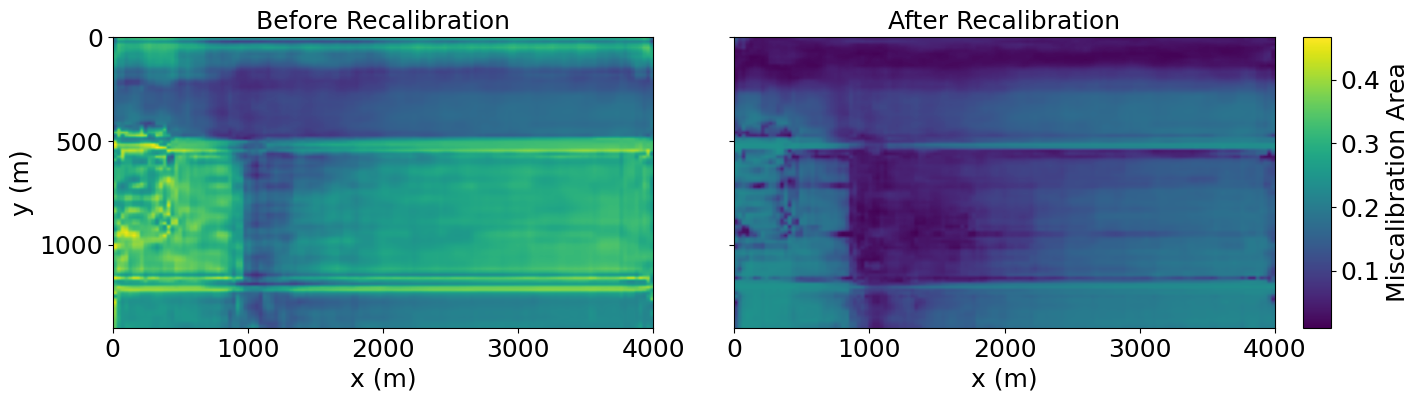

In [43]:
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from skimage.transform import resize

# -------------------------------
# Parámetros de fuente (aislados, no permanentes)
# -------------------------------
sizefont = 18
rc_backup = mpl.rcParams.copy()
dx = 10   # m
dy = 10   # m

try:
    plt.rcParams.update({
        "font.size":       sizefont,
        "axes.titlesize":  sizefont,
        "axes.labelsize":  sizefont,
        "xtick.labelsize": sizefont,
        "ytick.labelsize": sizefont,
    })

    # -------------------------------
    # Data list para este caso (usando lo cargado del JSON)
    # -------------------------------
    data_list  = [ma_before_map_loaded, ma_after_map_loaded]
    data_title = ["Before Recalibration", "After Recalibration"]

    # -------------------------------
    # Target shape, ejes físicos y resize
    # -------------------------------
    target_shape = (141, 401)          # (ny, nx)
    ny_t, nx_t   = target_shape
    x_vals_r = np.arange(nx_t) * dx    # 0, 10, 20, ..., 4000 m
    y_vals_r = np.arange(ny_t) * dy    # 0, 10, 20, ..., 1400 m

    data_list_resized = [
        resize(d, target_shape, order=1, preserve_range=True, anti_aliasing=True)
        for d in data_list
    ]

    # -------------------------------
    # Escala de color compartida entre ambos mapas
    # -------------------------------
    vmin = min(d.min() for d in data_list_resized)
    vmax = max(d.max() for d in data_list_resized)

    # -------------------------------
    # Proporciones físicas reales
    # -------------------------------
    phys_aspect = (ny_t * dy) / (nx_t * dx)
    fig_width   = 14
    col_width   = (fig_width - 0.5) / 2
    row_height  = col_width * phys_aspect

    # -------------------------
    # Subplot 1x2 Final
    # -------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(fig_width, row_height + 1.5)
    )
    fig.subplots_adjust(
        left=0.07, right=0.9,
        bottom=0.15, top=0.9,
        wspace=0.15,
    )

    im = None
    for i, ax in enumerate(axes.flat):
        im = ax.imshow(
            data_list_resized[i].T,
            extent=[x_vals_r[0], x_vals_r[-1], y_vals_r[0], y_vals_r[-1]],
            origin="lower",
            aspect="auto",
            vmin=vmin, vmax=vmax,
        )
        ax.set_title(data_title[i], fontsize=sizefont, pad=6)
        ax.set_xlabel("x (m)", fontsize=sizefont)
        ax.tick_params(axis="both", labelsize=sizefont)
        ax.invert_yaxis()

        if i == 0:
            ax.set_ylabel("y (m)", fontsize=sizefont)
        else:
            ax.tick_params(axis="y", labelleft=False)  # oculta los ticks/números del eje y

    # -------------------------------
    # Una sola barra de color compartida (a la derecha de todo)
    # -------------------------------
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.75])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Miscalibration Area", fontsize=sizefont)
    cbar.ax.tick_params(labelsize=sizefont)

    plt.savefig(
        dirImages + "miscalibration_area_heatmapsb.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

finally:
    mpl.rcParams.update(rc_backup)  # restaura tu estilo previo, pase lo que pase

# **8.3. Results**

In [44]:
batch_id = 3#2
x_batch, y_true = test_seq[batch_id] # x_batch: (8, 64, 64, 1)

S = 100 
mus = []
sig2s = []

In [45]:
preds_dist = model2(x_batch)

In [46]:
preds_dist.shape

TensorShape([8, 288, 96, 1])

In [47]:
preds_dist.mean().numpy().shape

(8, 288, 96, 1)

In [48]:
for i in range(S):
    # 'training=True' es la clave para que el Dropout actúe
    preds_dist = model2(x_batch) 
    
    # Extraemos media y varianza de la distribución de TF Probability
    mus.append(preds_dist.mean().numpy())
    sig2s.append(preds_dist.variance().numpy())

# Convertimos a arrays: (S, 8, 64, 64, 1)
mus = np.array(mus)
sig2s = np.array(sig2s)

In [49]:
print(mus.shape, sig2s.shape)

(100, 8, 288, 96, 1) (100, 8, 288, 96, 1)


In [50]:
# Media de todas las predicciones (Media Predicha)
y_pred_mean = np.mean(mus, axis=0)

# Incertidumbre Epistémica: Varianza de las medias
# Representa la duda del modelo sobre sus propios pesos
epistemic_var = np.var(mus, axis=0)

#Incertidumbre Aleatoria: Media de las varianzas
# Representa el ruido intrínseco de los datos
aleatoric_var = np.mean(sig2s, axis=0)

# Incertidumbre Total (Desviación estándar total)
total_std = np.sqrt(epistemic_var + aleatoric_var)

In [51]:
print(y_pred_mean.shape,epistemic_var.shape,aleatoric_var.shape,total_std.shape)

(8, 288, 96, 1) (8, 288, 96, 1) (8, 288, 96, 1) (8, 288, 96, 1)


In [52]:
# --- REDEFINICIÓN LOCAL DE EJES (Para evitar KerasTensor) ---
# Usamos las dimensiones que ya conoces: nx=64, ny=64, dx=10, dy=10
nx=288
ny=96
dx=dy=10
x_vals = np.arange(nx) * dx
y_vals = np.arange(ny) * dy
sizefont=12
idx_ejemplo=2#(Batch,id))=(28,6) / (0,5) / (2,7) / (15,6)

In [53]:
def to_numpy(x):
    return x.numpy() if hasattr(x, "numpy") else x


In [54]:
img_true = to_numpy(y_true[idx_ejemplo, ..., 0])
img_pred = to_numpy(y_pred_mean[idx_ejemplo, ..., 0])
img_ale  = to_numpy(aleatoric_var[idx_ejemplo, ..., 0])
img_epi  = to_numpy(epistemic_var[idx_ejemplo, ..., 0])
img_total_std=to_numpy(total_std[idx_ejemplo, ..., 0])

In [55]:
from skimage.transform import resize

# -------------------------------
# Parámetros físicos
# -------------------------------
dx = 10   # m
dy = 10   # m

# -------------------------------
# Desnormalización
# -------------------------------
v_min = vmin_global
v_max = vmax_global
dv    = v_max - v_min

img_true_dn = img_true * dv + v_min
img_pred_dn = img_pred * dv + v_min

# Las incertidumbres NO se desnormalizan como velocidad
img_ale_dn  = img_ale * dv
img_epi_dn  = img_epi * dv

data_list  = [img_true_dn, img_pred_dn, img_ale_dn, img_epi_dn]
data_title = [
    "Reference Model Velocity",
    "Predicted Model Velocity",
    "Aleatoric Uncertainty",
    "Epistemic Uncertainty",
]

# -------------------------------
# Resize a (141, 401) con dx=dy=10
# -------------------------------
target_shape = (141, 401)          # (ny, nx)
ny_t, nx_t   = target_shape

x_vals_r = np.arange(nx_t) * dx   # 0, 10, ..., 4000 m
y_vals_r = np.arange(ny_t) * dy   # 0, 10, ..., 1400 m

data_list_resized = [
    resize(d, target_shape, order=1, preserve_range=True, anti_aliasing=True)
    for d in data_list
]

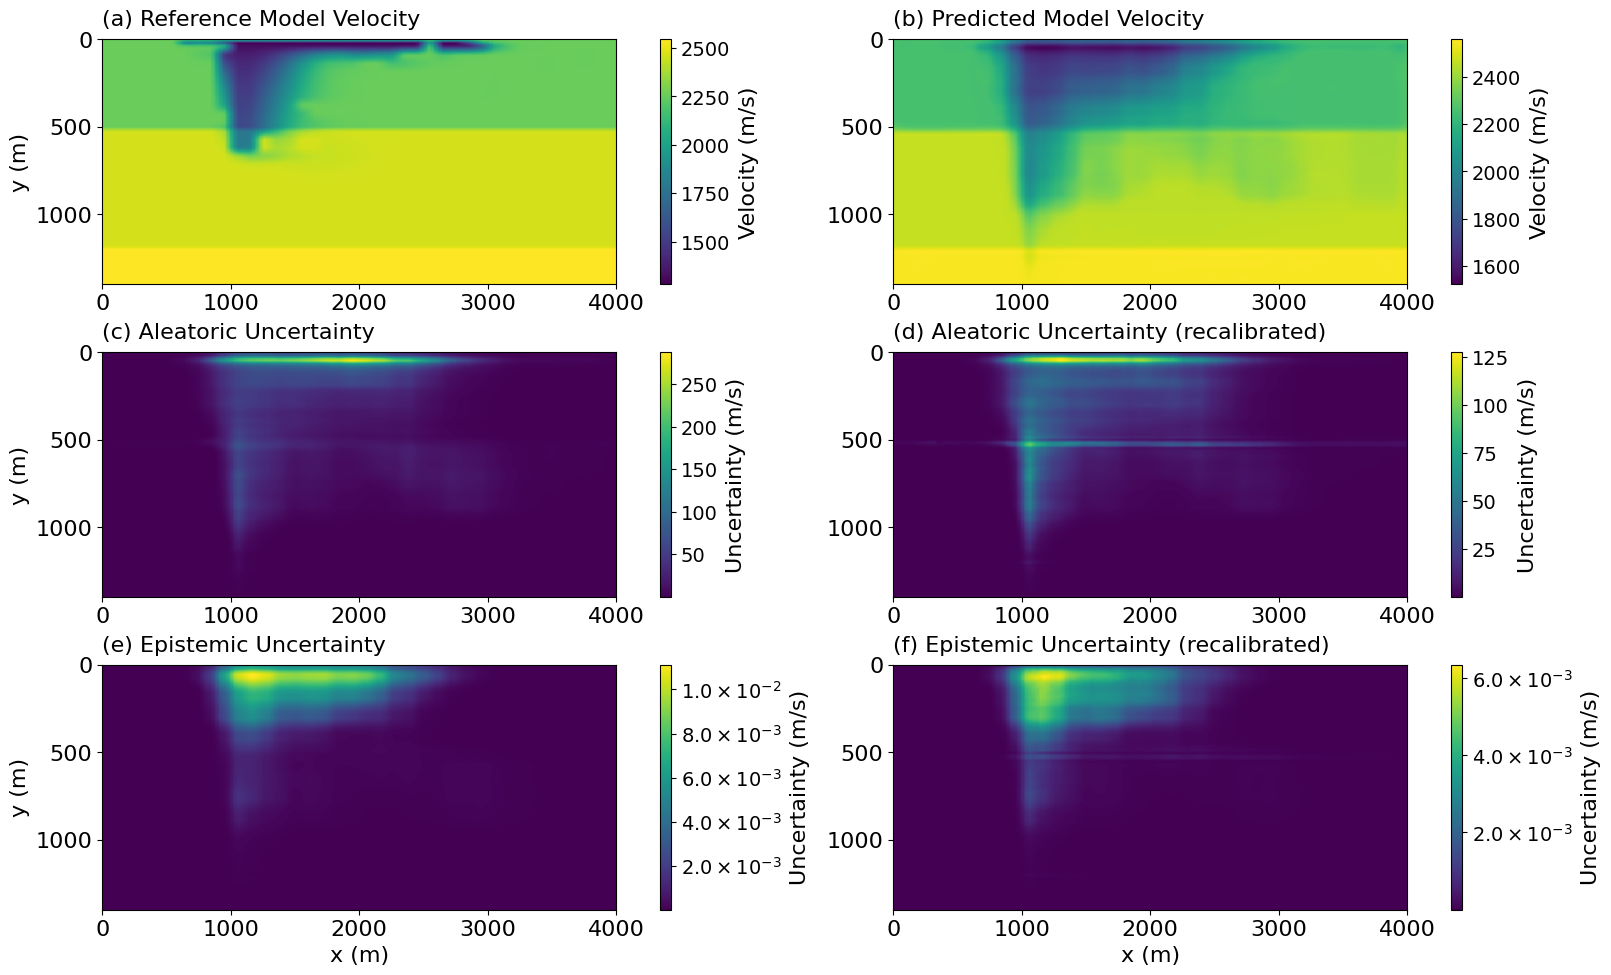

In [56]:
# -------------------------------
# Cargar el ratio de recalibración
# -------------------------------
std_recal_ratio_map = np.load(os.path.join(dirModel, "std_recal_ratio_map.npy"))
with open(os.path.join(dirModel, "std_recal_ratio_metadata.json")) as f:
    metadata = json.load(f)

# -------------------------------
# Incertidumbres recalibradas
# -------------------------------
img_ale_recal_dn = img_ale_dn * std_recal_ratio_map
img_epi_recal_dn = img_epi_dn * std_recal_ratio_map

# -------------------------------
# Lista combinada
# -------------------------------
combined_list = [
    img_true_dn, img_pred_dn,
    img_ale_dn, img_ale_recal_dn,
    img_epi_dn, img_epi_recal_dn,
]
combined_titles = [
    "Reference Model Velocity",
    "Predicted Model Velocity",
    "Aleatoric Uncertainty",
    "Aleatoric Uncertainty (recalibrated)",
    "Epistemic Uncertainty",
    "Epistemic Uncertainty (recalibrated)",
]

# -------------------------------
# Parámetros de fuente (formato original)
# -------------------------------
sizefont = 16
plt.rcParams.update({
    "font.size":       sizefont,
    "axes.titlesize":  sizefont,
    "axes.labelsize":  sizefont,
    "xtick.labelsize": sizefont,
    "ytick.labelsize": sizefont,
})

# -------------------------------
# Target shape, ejes físicos y resize
# -------------------------------
target_shape = (141, 401)
ny_t, nx_t   = target_shape
x_vals_r = np.arange(nx_t) * dx
y_vals_r = np.arange(ny_t) * dy
combined_resized = [
    resize(d, target_shape, order=1, preserve_range=True, anti_aliasing=True)
    for d in combined_list
]

# -------------------------------
# Proporciones físicas reales
# -------------------------------
phys_aspect = (ny_t * dy) / (nx_t * dx)   # alto/ancho de cada panel

# Tamaño de figura ampliado: cada subplot más grande
fig_width_per_col = 8.0
ncols_ = 2
nrows_ = 3
col_width  = fig_width_per_col
row_height = col_width * phys_aspect

fig_width  = col_width * ncols_
fig_height = row_height * nrows_ + 1.2

# -------------------------
# Formato: enteros sin decimales, no enteros en notación
# científica LaTeX (mathtext), 1 decimal en la mantisa
# -------------------------
mantissa_decimals = 1
def sci_latex(x, decimals=1):
    if x == 0:
        return "0"
    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / (10 ** exponent)
    return f"${mantissa:.{decimals}f} \\times 10^{{{exponent}}}$"

def smart_fmt(x, pos):
    if float(x).is_integer():
        return f"{int(x)}"
    return sci_latex(x, mantissa_decimals)

fmt = FuncFormatter(smart_fmt)

# -------------------------
# Subplot 3x2 con constrained_layout
# -------------------------
nrows, ncols = nrows_, ncols_
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(fig_width, fig_height),
    constrained_layout=True,
)
axes_flat = np.array(axes).flatten()
n_plots = len(combined_list)
panel_labels = list(string.ascii_lowercase)

for i, ax in enumerate(axes_flat):
    im = ax.imshow(
        combined_resized[i].T,
        extent=[x_vals_r[0], x_vals_r[-1], y_vals_r[0], y_vals_r[-1]],
        origin="lower",
        aspect="auto",
    )

    ax.set_title(f"({panel_labels[i]}) {combined_titles[i]}",
                 fontsize=sizefont, pad=10, loc="left")

    if i >= n_plots - ncols:
        ax.set_xlabel("x (m)", fontsize=sizefont)
    if i % ncols == 0:
        ax.set_ylabel("y (m)", fontsize=sizefont)

    ax.tick_params(axis="both", labelsize=sizefont)
    ax.invert_yaxis()

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, aspect=22)
    cbar.ax.yaxis.set_major_formatter(fmt)
    cbar.ax.tick_params(labelsize=sizefont - 2)

    label = "Velocity (m/s)" if i < 2 else "Uncertainty (m/s)"
    cbar.set_label(label, fontsize=sizefont, labelpad=6)

fig.set_constrained_layout_pads(w_pad=0.1, h_pad=0.1, hspace=0.03, wspace=0.05)

plt.savefig(
    dirImages + "full_recal_figure-FPN-B2-i7-NegLik40-j" + str(idx_ejemplo) + ".png",
    dpi=300, bbox_inches="tight"
)
plt.show()
plt.close(fig) 